# Analyzing London Public Transport Usage with SQL

## Project Overview

Transport for London (TfL) manages one of the world's largest urban transportation networks. This project analyzes passenger journey data across different transport modes to identify usage patterns, peak demand periods, and long-term trends using SQL queries.

## Objectives

- Identify the most popular transport services.
- Analyze peak ridership periods for Emirates Airline.
- Determine the years with the lowest Underground & DLR demand.
- Explore overall transport demand trends.

## Data Dictionary

| Column            | Description                   |
| ----------------- | ----------------------------- |
| MONTH             | Month of the observation      |
| YEAR              | Year of the observation       |
| DAYS              | Number of days in the month   |
| REPORT_DATE       | Date reported                 |
| JOURNEY_TYPE      | Transport service category    |
| JOURNEYS_MILLIONS | Passenger journeys (millions) |


## Data Preparation

In [1]:
# Import necessary libraries

# Data manipulation
import pandas as pd

# Data visualization
import duckdb

# Set the style for seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)

In [2]:
#Load the dataset
df = pd.read_excel('../data/raw/london_public_transport.xlsx')

# Display the first few rows of the dataset
df.head()

,index,MONTH,YEAR,DAYS,REPORT_DATE,JOURNEY_TYPE,JOURNEYS_MILLIONS
0,0,1,2010,31,2010-06-30T00:00:00.000,Underground & DLR,96.836391
1,1,2,2010,28,2010-06-30T00:00:00.000,Underground & DLR,90.330504
2,2,3,2010,31,2010-06-30T00:00:00.000,Underground & DLR,90.038014
3,3,4,2010,30,2010-09-30T00:00:00.000,Underground & DLR,92.544093
4,4,5,2010,31,2010-09-30T00:00:00.000,Underground & DLR,88.662911


In [3]:
#Data Validation

#Dataset information
df.info()

# Check for missing values
df.isna().sum()

#Unique values in JOURNEY_TYPE column
df['JOURNEY_TYPE'].nunique()

<class 'pandas.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              936 non-null    int64  
 1   MONTH              936 non-null    int64  
 2   YEAR               936 non-null    int64  
 3   DAYS               936 non-null    int64  
 4   REPORT_DATE        936 non-null    str    
 5   JOURNEY_TYPE       936 non-null    str    
 6   JOURNEYS_MILLIONS  841 non-null    float64
dtypes: float64(1), int64(4), str(2)
memory usage: 51.3 KB


6

In [4]:
#Create DuckDB connection

#Connect to DuckDB
con = duckdb.connect()

#Register the DataFrame as a table in DuckDB
con.register('london_transport', df)

## Analysis

### Most Popular Transport Types

The following query aggregates passenger journeys by transport mode to identify the most frequently used services.

In [6]:
# Analyze the most popular transport types based on the total number of journeys
most_popular_transport_types = con.sql("""
    SELECT
        journey_type,
        ROUND(SUM(journeys_millions), 2) AS total_journeys_millions
    FROM london_transport
    GROUP BY journey_type
    ORDER BY total_journeys_millions DESC
""").df()

most_popular_transport_types

,JOURNEY_TYPE,total_journeys_millions
0,Bus,24905.19
1,Underground & DLR,15020.47
2,Overground,1666.85
3,TfL Rail,411.31
4,Tram,314.69
5,Emirates Airline,14.58


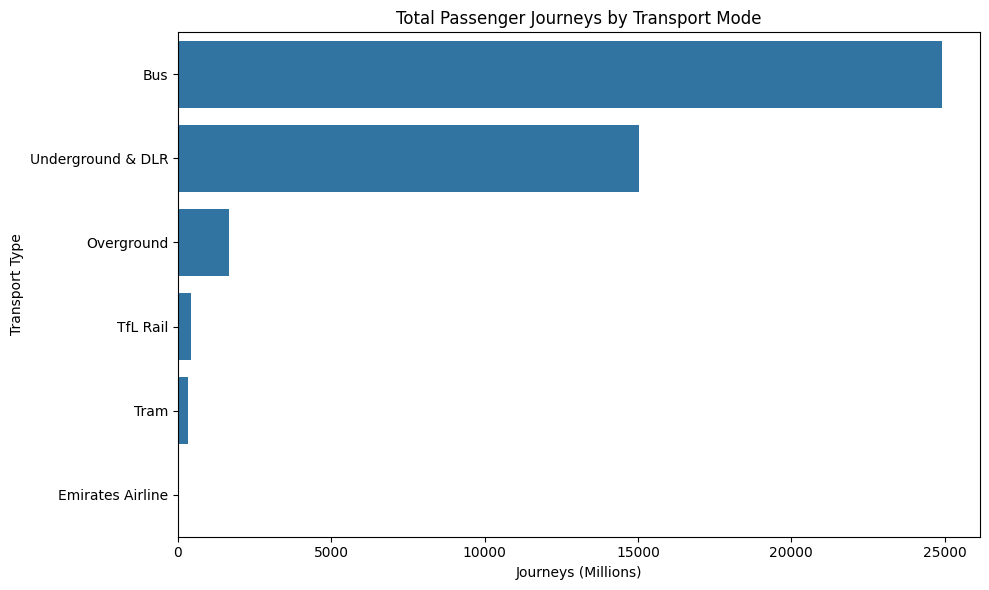

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=most_popular_transport_types,
    x="total_journeys_millions",
    y="JOURNEY_TYPE",
)

plt.title("Total Passenger Journeys by Transport Mode")
plt.xlabel("Journeys (Millions)")
plt.ylabel("Transport Type")

plt.tight_layout()
plt.show()

### Emirates Airline Peak Demand

This query identifies the five months with the highest passenger volumes for Emirates Airline, highlighting periods of peak demand.

In [11]:
emirates_airline_popularity = con.sql("""
    SELECT
        month,
        year,
        ROUND(journeys_millions, 2) AS rounded_journeys_millions
    FROM london_transport
    WHERE journey_type = 'Emirates Airline'
      AND journeys_millions IS NOT NULL
    ORDER BY rounded_journeys_millions DESC
    LIMIT 5
""").df()

emirates_airline_popularity

,MONTH,YEAR,rounded_journeys_millions
0,5,2012,0.53
1,6,2012,0.38
2,4,2012,0.24
3,5,2013,0.19
4,5,2015,0.19


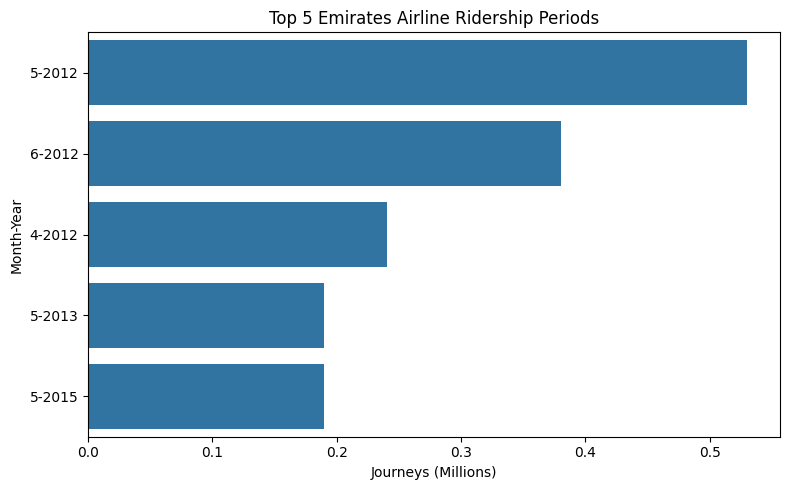

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=emirates_airline_popularity,
    x="rounded_journeys_millions",
    y=emirates_airline_popularity["MONTH"].astype(str)
      + "-"
      + emirates_airline_popularity["YEAR"].astype(str)
)

plt.title("Top 5 Emirates Airline Ridership Periods")
plt.xlabel("Journeys (Millions)")
plt.ylabel("Month-Year")

plt.tight_layout()
plt.show()

### Least Popular Years for Underground & DLR

The following query identifies the five years with the lowest passenger demand for the Underground & DLR network based on total annual journeys.

In [14]:
least_popular_years_tube = con.sql("""
    SELECT
        year,
        journey_type,
        ROUND(SUM(journeys_millions), 2) AS total_journeys_millions
    FROM london_transport
    WHERE journey_type = 'Underground & DLR'
    GROUP BY year, journey_type
    ORDER BY total_journeys_millions
    LIMIT 5
""").df()

least_popular_years_tube

,YEAR,JOURNEY_TYPE,total_journeys_millions
0,2020,Underground & DLR,310.18
1,2021,Underground & DLR,748.45
2,2022,Underground & DLR,1064.86
3,2010,Underground & DLR,1096.15
4,2011,Underground & DLR,1156.65


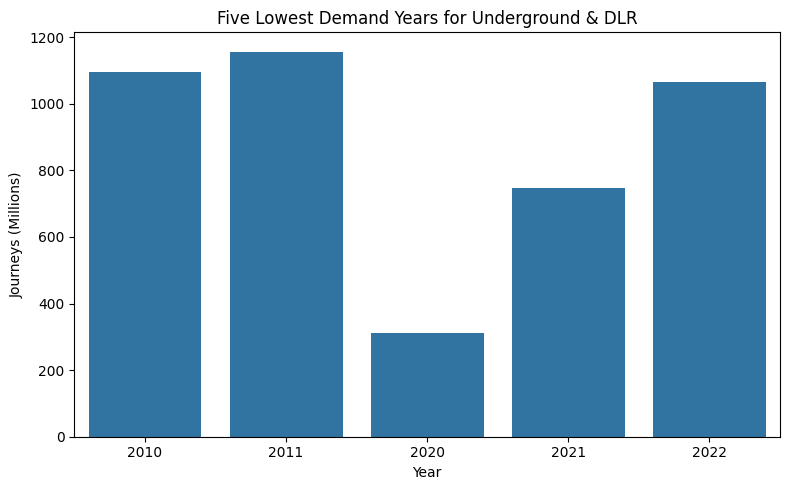

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=least_popular_years_tube,
    x="YEAR",
    y="total_journeys_millions"
)

plt.title("Five Lowest Demand Years for Underground & DLR")
plt.xlabel("Year")
plt.ylabel("Journeys (Millions)")

plt.tight_layout()
plt.show()

### Annual Transport Demand Trend

The original analysis focuses on specific transport modes and periods. To provide a broader view of the dataset, this query examines how total passenger demand evolved across the entire Transport for London (TfL) network over time.

In [24]:
# Analyze annual passenger demand across the entire transport network
annual_journeys = con.sql("""
    SELECT
        YEAR,
        ROUND(SUM(journeys_millions), 2) AS total_journeys_millions
    FROM london_transport
    GROUP BY year
    ORDER BY year
""").df()

annual_journeys

,YEAR,total_journeys_millions
0,2010,3261.88
1,2011,3429.60
2,2012,3517.05
3,2013,3580.34
4,2014,3626.80
5,2015,3752.51
6,2016,3714.69
7,2017,3678.44
8,2018,3672.71
9,2019,3633.53


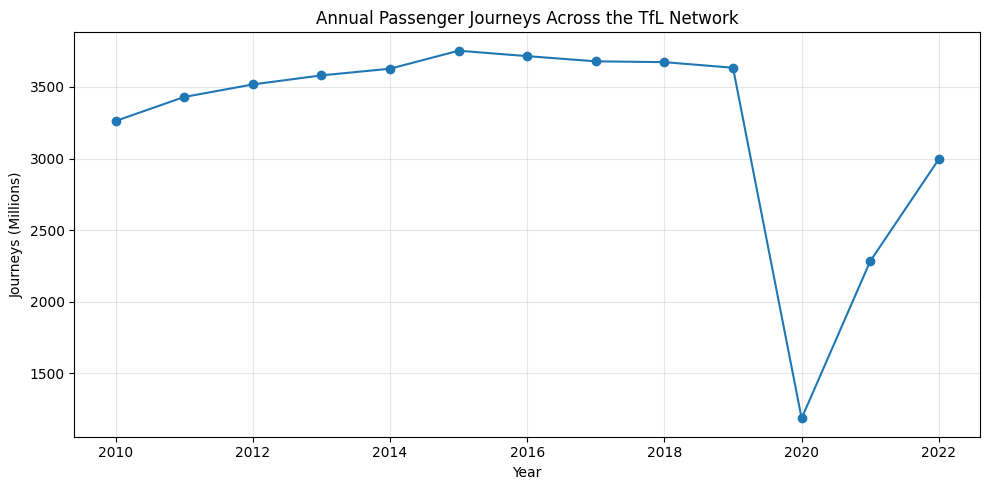

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    annual_journeys["YEAR"],
    annual_journeys["total_journeys_millions"],
    marker="o"
)

plt.title("Annual Passenger Journeys Across the TfL Network")
plt.xlabel("Year")
plt.ylabel("Journeys (Millions)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Key Findings

- Bus was the most widely used transport mode, recording the highest cumulative passenger volume during the analyzed period, followed by Underground & DLR.
- Emirates Airline represented a relatively small share of total journeys, with its highest ridership levels concentrated between 2012 and 2015.
- Underground & DLR experienced substantial fluctuations in annual demand, with 2020 showing the lowest recorded passenger volume among the analyzed years.
- Passenger demand across the TfL network changed over time, revealing periods of decline and subsequent recovery in overall ridership.
- The transport network exhibited a clear concentration of demand in a small number of transport modes, particularly Bus and Underground & DLR, which accounted for the majority of journeys.

## Conclusions

This project analyzed passenger journey data from Transport for London (TfL) using SQL queries executed through DuckDB. The results show that Bus and Underground & DLR were the dominant transport modes, accounting for the largest share of journeys across the network.

The analysis also highlighted distinct demand patterns among services. While Emirates Airline reached peak ridership during a limited number of periods, Underground & DLR experienced notable year-to-year fluctuations, including a significant reduction in passenger volumes during some years.

Finally, the annual demand trend provided a broader view of network usage, showing that passenger volumes evolved over time rather than remaining constant. Together, these findings demonstrate how SQL can be used to efficiently aggregate, filter, and analyze transportation data to uncover meaningful patterns in public transport usage.